# Phase 3 — Inference-parameter optimization & test-fold generalization

Cellpose-SAM (CPSAM, v4.1.1) fine-tuning pipeline — trigeminal-ganglion neuron segmentation.

This notebook implements **Methods 2.4.3** of the manuscript:

1. **Derive** `diameter` and `min_size` from morphological analysis (`regionprops`) of the **validation** ground truth.
2. **Grid search** over `flow_threshold` × `cellprob_threshold` on the **independent validation set** (the 4 `Valid*` images), for **each of the 10 fold models** (A = no augmentation, B = with augmentation). Selection metric = **AP@50**.
3. **Re-evaluate** every model on **its own cross-validation test fold** using the fixed inference parameters, to check whether the choices made on validation generalize.
4. **Compare** augmentation vs no-augmentation **after** the segmentation parameters have been refined, and quantify the change relative to the phase-2 (default-threshold) results.

Outputs are written as JSON/CSV mirroring the structure of your phase-2 k-fold files, plus a Figure-5-style box plot.

> **Two things to confirm before running** (see the CONFIG cell):
> - `CV_IMAGES_DIR` / `CV_GT_DIR` — where the 26 cross-validation images + `_seg.npy` masks live (needed for step 3).
> - `USE_MORPH_DIAMETER` — the folds were fine-tuned with `diameter=None` (native scale); this toggle lets you apply the morphology-derived diameter (as written in the Methods) **or** keep `None`, and compare.


## 1 · Setup

In [ ]:
# --- Colab: install the pinned version used in the paper (uncomment) ---------
!pip install "cellpose==4.2.1.1" scikit-image tifffile pandas matplotlib --quiet


In [ ]:
import os, re, json, time, gc
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
from skimage.measure import regionprops

from cellpose import models
from cellpose import metrics as cp_metrics

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **k):
        return x

try:
    import torch
    print("Torch CUDA available:", torch.cuda.is_available())
except Exception:
    torch = None
    print("torch not importable in this environment")


Torch CUDA available: True


## 2 · Configuration

Everything you might want to change lives here. Paths follow the layout in your notebook /
phase-2 JSONs; the two lines marked `EDIT ME` are the ones I could not infer.

# ⚠️ IMPORTANT: External Data Requirement
To use this notebook, you must provide your own histology dataset.
If you do not have access, please request it from the research team.
Required Directory Structure:
 Place your data in a folder named ./dataset/ with the following subdirectories:
 - ./dataset/groundtruths/validation
- ./dataset/groundtruths/


In [ ]:
import os, shutil
from pathlib import Path
import numpy as np

# ⚠️ IMPORTANT: External Data Requirement
# To use this notebook, you must provide your own histology dataset.
# If you do not have access, please request it from the research team.
# Required Directory Structure:
# Place your data in a folder named ./dataset/ with the following subdirectories:
# - ./dataset/groundtruths/validation
# - ./dataset/groundtruths/

PROJECT_ROOT = Path('./dataset')

# === Data Directories ===
VALIDATION_IMAGES_DIR = PROJECT_ROOT / 'groundtruths/validation'
VALIDATION_GT_DIR     = PROJECT_ROOT / 'groundtruths/validation'

CV_IMAGES_DIR = PROJECT_ROOT / 'groundtruths'
CV_GT_DIR     = PROJECT_ROOT / 'groundtruths'

# === Model Result JSONs (Phase 2) ===
PHASE2_JSON_A = PROJECT_ROOT / 'results/A_no_augmentation_default/results.json'
PHASE2_JSON_B = PROJECT_ROOT / 'results/B_with_augmentation_default/results.json'

# === Outputs ===
OUTPUT_DIR = Path('./outputs/phase3_inference_optimization')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# === Grid Search Parameters ===
FLOW_THRESHOLDS     = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
CELLPROB_THRESHOLDS = [-2.0, -1.0, 0.0, 1.0, 2.0]

# === Morphology Rules ===
USE_MORPH_DIAMETER  = True
DIAMETER_RULE       = 'mean'
MIN_SIZE_RULE       = 'min'
MIN_SIZE_PERCENTILE = 1.0

# === Constants ===
TRAIN_HP = dict(n_epochs=100, learning_rate=1e-5, weight_decay=0.1, batch_size=1)
IOU_THRESHOLDS = [0.5, 0.75, 0.9]
CHANNEL_AXIS   = -1
USE_GPU        = True
EPS            = 1e-9

Mounted at /content/drive


## 3 · Helper functions

I/O, file pairing, and a metric function that reproduces the phase-2 convention exactly:

- **AP / TP / FP / FN** come from `cellpose.metrics.average_precision` (AP = TP / (TP+FP+FN)).
- **per-image** Precision/Recall/F1 use that image's counts.
- **aggregate** AP = *mean of per-image AP* (macro); aggregate Precision/Recall/F1 are computed from *pooled* TP/FP/FN (micro). This matches your k-fold JSON to the ninth decimal.

In [ ]:
def load_image_rgb(path):
    img = np.asarray(tifffile.imread(str(path)))
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    elif img.ndim == 3:
        if img.shape[0] in (3, 4) and img.shape[-1] not in (3, 4):   # channel-first -> last
            img = np.moveaxis(img, 0, -1)
        if img.shape[-1] == 4:                                       # drop alpha
            img = img[..., :3]
    return np.ascontiguousarray(img)


def load_masks(path):
    arr = np.load(str(path), allow_pickle=True)
    try:
        d = arr.item()
        if isinstance(d, dict) and 'masks' in d:
            return np.asarray(d['masks']).astype(np.int32)
    except Exception:
        pass
    return np.asarray(arr).astype(np.int32)


_DIGITS = re.compile(r'(\d+)')
def id_from_name(name):
    m = _DIGITS.findall(Path(name).stem)
    return m[-1] if m else Path(name).stem


def build_validation_index(img_dir, gt_dir):
    # Pair every validation image with its <stem>_seg.npy.
    # Keys are the FULL filename stem (not an extracted integer), so names like
    # '3.2.2' and 'Valid2' never collide. Case-insensitive extension match.
    # Images without a matching mask are reported and skipped.
    img_dir, gt_dir = Path(img_dir), Path(gt_dir)
    exts = ('.tif', '.tiff', '.png', '.jpg', '.jpeg', '.bmp')
    imgs = ([p for p in img_dir.iterdir()
             if p.is_file() and p.suffix.lower() in exts
             and '_seg' not in p.stem and '_masks' not in p.stem]
            if img_dir.exists() else [])
    img_by_id, gt_by_id, missing = {}, {}, []
    for p in sorted(imgs):
        key = p.stem                                    # full stem -> no collisions
        img_by_id[key] = p
        cand = list(gt_dir.glob(f'{p.stem}_seg.npy')) or list(gt_dir.glob(f'{p.stem}*seg*.npy'))
        if cand:
            gt_by_id[key] = cand[0]
        else:
            missing.append(p.name)
    ids = sorted(k for k in img_by_id if k in gt_by_id)
    print(f'[validation] {len(imgs)} image(s) found; {len(ids)} paired with a mask -> {ids}')
    if missing:
        print(f'[validation] WARNING: {len(missing)} image(s) have NO matching _seg.npy '
              f'(excluded from calibration): {missing}')
    return ids, img_by_id, gt_by_id


def resolve_cv_pair(image_id, img_dir, gt_dir):
    img_dir, gt_dir = Path(img_dir), Path(gt_dir)
    img = None
    for ext in ('tif', 'tiff', 'TIF', 'TIFF', 'png', 'jpg'):
        c = list(img_dir.glob(f'{image_id}.{ext}'))
        if c:
            img = c[0]; break
    if img is None:                                                  # strict fallback
        c = [p for p in img_dir.iterdir()
             if p.stem == str(image_id) and p.suffix.lower() in ('.tif', '.tiff', '.png', '.jpg')]
        img = c[0] if c else None
    gt = None
    for pat in (f'{image_id}_seg.npy', f'{image_id}_masks.npy', f'{image_id}*seg*.npy'):
        c = list(gt_dir.glob(pat))
        if c:
            gt = c[0]; break
    return img, gt


In [ ]:
def compute_metrics(gt_list, pred_list, thresholds=IOU_THRESHOLDS, eps=EPS):
    # Reproduces the phase-2 metric convention (see markdown above).
    ap, tp, fp, fn = cp_metrics.average_precision(gt_list, pred_list, threshold=thresholds)
    ap, tp, fp, fn = map(np.atleast_2d, (ap, tp, fp, fn))            # -> (n_img, n_thr)
    per_image, aggregate = {}, {}
    for ti, thr in enumerate(thresholds):
        key = f'AP@{thr}'
        P = tp[:, ti] / (tp[:, ti] + fp[:, ti] + eps)
        R = tp[:, ti] / (tp[:, ti] + fn[:, ti] + eps)
        F1 = 2 * P * R / (P + R + eps)
        per_image[key] = dict(
            AP=ap[:, ti].tolist(),
            TP=tp[:, ti].astype(int).tolist(),
            FP=fp[:, ti].astype(int).tolist(),
            FN=fn[:, ti].astype(int).tolist(),
            Precision=P.tolist(), Recall=R.tolist(), F1=F1.tolist())
        TP, FP, FN = int(tp[:, ti].sum()), int(fp[:, ti].sum()), int(fn[:, ti].sum())
        Pa = TP / (TP + FP + eps)
        Ra = TP / (TP + FN + eps)
        F1a = 2 * Pa * Ra / (Pa + Ra + eps)
        aggregate[key] = dict(AP=float(ap[:, ti].mean()),
                              TP=TP, FP=FP, FN=FN,
                              Precision=Pa, Recall=Ra, F1=F1a)
    return aggregate, per_image


def to_py(o):
    if isinstance(o, dict):
        return {k: to_py(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [to_py(v) for v in o]
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.floating):
        return float(o)
    if isinstance(o, np.ndarray):
        return to_py(o.tolist())
    return o


def save_json(obj, path):
    with open(path, 'w') as f:
        json.dump(to_py(obj), f, indent=4)
    print('saved ->', path)


## 4 · Validation set → derive `diameter` and `min_size`

`regionprops` runs over **every** GT object in **all paired** validation images (the cell prints how
many it found and pairs). The equivalent-diameter distribution sets `diameter`; the area distribution
sets `min_size`.

**Consistency check.** The per-image breakdown below lets you reconcile against the summary you
shared: mean EqDiam ≈ **105 px** (median ≈ 100), smallest area ≈ 1354 px, ~299 objects across 4
images. Your `validation/` folder currently holds **5** `.tif` (`3.2.2`, `Valid1–4`); if `3.2.2` has a
matching `_seg.npy` it will be **included here**, so the totals/`diameter` may shift from the 4-image
summary. If `3.2.2` should not be part of calibration, remove it (or its mask) from the folder.

In [ ]:
val_ids, VAL_IMG_BY_ID, VAL_GT_BY_ID = build_validation_index(VALIDATION_IMAGES_DIR, VALIDATION_GT_DIR)
if len(val_ids) == 0:
    d = Path(VALIDATION_IMAGES_DIR)
    print('\n[diagnosis] VALIDATION_IMAGES_DIR =', d)
    print('            folder exists   =', d.exists())
    print('            Drive mounted?  =', Path('/content/drive/MyDrive').exists())
    if d.exists():
        entries = sorted(d.iterdir())
        print(f'            {len(entries)} entries in the folder:')
        for p in entries[:60]:
            print(f'               {p.name}   (suffix={p.suffix})')
        seg = [p.name for p in entries if p.suffix.lower() == '.npy']
        print('            _seg.npy masks present:', seg)
    else:
        print('            -> folder NOT found. Two usual causes:')
        print('               1) Google Drive is not mounted: uncomment the two')
        print('                  `drive.mount(...)` lines at the top of the CONFIG cell and re-run.')
        print('               2) The path is wrong: fix VALIDATION_IMAGES_DIR / PROJECT_ROOT.')
    raise FileNotFoundError('No validation image/GT pairs found — see [diagnosis] above.')

val_images = [load_image_rgb(VAL_IMG_BY_ID[i]) for i in val_ids]
val_gts    = [load_masks(VAL_GT_BY_ID[i])      for i in val_ids]
val_names  = list(val_ids)

# --- morphology over all validation GT objects, tracked per image -----------
eqdiam, areas = [], []
print(f'{"image":<12} {"shape":>16} {"n_obj":>7} {"meanEqDiam":>11} {"minArea":>9}')
for i, im, g in zip(val_ids, val_images, val_gts):
    rps = regionprops(g)
    d = np.array([r.equivalent_diameter for r in rps])
    a = np.array([r.area for r in rps])
    eqdiam.extend(d.tolist()); areas.extend(a.tolist())
    print(f'{i:<12} {str(im.shape):>16} {len(rps):>7} '
          f'{(d.mean() if len(d) else 0):>11.2f} {(a.min() if len(a) else 0):>9.0f}')
eqdiam, areas = np.array(eqdiam), np.array(areas)

print(f'\nGT objects total = {len(areas)}   (paired images = {len(val_ids)})')
print(f'EqDiam(px): mean={eqdiam.mean():.2f}  median={np.median(eqdiam):.2f}  '
      f'min={eqdiam.min():.2f}  max={eqdiam.max():.2f}')
print(f'Area(px):   mean={areas.mean():.1f}  median={np.median(areas):.1f}  '
      f'min={areas.min():.1f}  p1={np.percentile(areas,1):.1f}')

# soft consistency check against the summary you shared (4 images, 299 objects)
REF_N_OBJECTS = 299
if len(areas) != REF_N_OBJECTS:
    print(f'\n[note] object count {len(areas)} != reference {REF_N_OBJECTS}: the paired set differs '
          f'from the 4-image morphology summary (likely 3.2.2 is now included/excluded).')

DIAMETER = None
if USE_MORPH_DIAMETER:
    DIAMETER = float(np.median(eqdiam) if DIAMETER_RULE == 'median' else eqdiam.mean())
if MIN_SIZE_RULE == 'percentile':
    MIN_SIZE = int(np.floor(np.percentile(areas, MIN_SIZE_PERCENTILE)))
else:                                            # 'min' -> smallest real object
    MIN_SIZE = int(np.floor(areas.min()))

print(f'\n>>> DIAMETER = {DIAMETER}   (USE_MORPH_DIAMETER={USE_MORPH_DIAMETER}, rule={DIAMETER_RULE})')
print(f'>>> MIN_SIZE = {MIN_SIZE}   (rule={MIN_SIZE_RULE}; smallest GT area = {areas.min():.0f})')


[validation] 5 image(s) found; 5 paired with a mask -> ['3.2.2', 'Valid1', 'Valid2', 'Valid3', 'Valid4']
image                   shape   n_obj  meanEqDiam   minArea
3.2.2         (1920, 2560, 3)      47      100.60      1959
Valid1        (1920, 2560, 3)      34      103.21      1354
Valid2        (1920, 2560, 3)      76      101.26      1848
Valid3        (1920, 2560, 3)      91      106.23      1605
Valid4        (1920, 2560, 3)      98      107.65      1902

GT objects total = 346   (paired images = 5)
EqDiam(px): mean=104.48  median=98.84  min=41.52  max=221.08
Area(px):   mean=9452.6  median=7672.5  min=1354.0  p1=1866.0

[note] object count 346 != reference 299: the paired set differs from the 4-image morphology summary (likely 3.2.2 is now included/excluded).

>>> DIAMETER = 104.47918282735914   (USE_MORPH_DIAMETER=True, rule=mean)
>>> MIN_SIZE = 1354   (rule=min; smallest GT area = 1354)


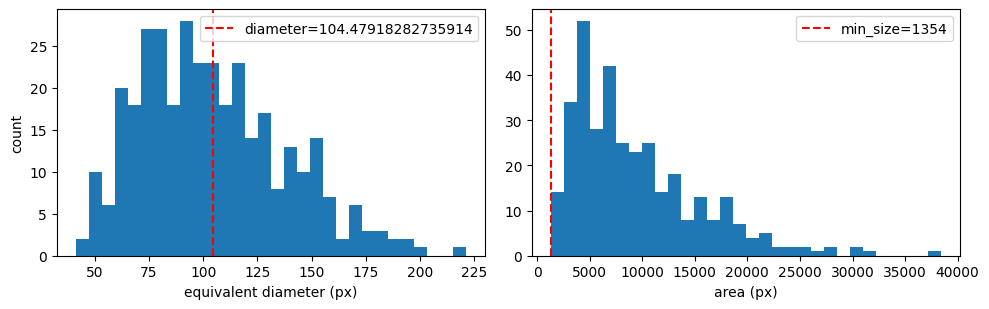

In [ ]:
# Optional: distributions used to set the two parameters
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].hist(eqdiam, bins=30); ax[0].axvline(DIAMETER if DIAMETER else eqdiam.mean(),
           color='r', ls='--', label=f'diameter={DIAMETER}')
ax[0].set_xlabel('equivalent diameter (px)'); ax[0].set_ylabel('count'); ax[0].legend()
ax[1].hist(areas, bins=30); ax[1].axvline(MIN_SIZE, color='r', ls='--', label=f'min_size={MIN_SIZE}')
ax[1].set_xlabel('area (px)'); ax[1].legend()
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'phase3_validation_morphology.png', dpi=150,
                                bbox_inches='tight'); plt.show()


## 5 · Load the phase-2 model registry

We read your two k-fold JSONs to get, for every model: `model_path`, `fold`, `test_image_names`,
`n_train`, and the augmentation flag — so the test-fold re-evaluation uses the **exact same splits**.

In [ ]:
def load_phase2(json_path, condition_label):
    with open(json_path) as f:
        data = json.load(f)
    for rec in data:
        rec['_condition'] = condition_label
    return data

registry = (load_phase2(PHASE2_JSON_A, 'A_no_augmentation') +
            load_phase2(PHASE2_JSON_B, 'B_with_augmentation'))
print(f'Loaded {len(registry)} models\n')
for r in registry:
    print(f"  {r['_condition']:20s} fold {r['fold']} | aug={r['use_augmentation']!s:5s} "
          f"| test={r['test_image_names']} | {Path(r['model_path']).name}")


Loaded 10 models

  A_no_augmentation    fold 1 | aug=False | test=['11', '20', '21', '23', '4', '17'] | A_no_augmentation_180_fold_1_ep100_lr1e-05_wd0.1.pth
  A_no_augmentation    fold 2 | aug=False | test=['12', '13', '18', '25', '15'] | A_no_augmentation_180_fold_2_ep100_lr1e-05_wd0.1.pth
  A_no_augmentation    fold 3 | aug=False | test=['14', '16', '24', '3', '1'] | A_no_augmentation_180_fold_3_ep100_lr1e-05_wd0.1.pth
  A_no_augmentation    fold 4 | aug=False | test=['5', '6', '9', '10', '7'] | A_no_augmentation_180_fold_4_ep100_lr1e-05_wd0.1.pth
  A_no_augmentation    fold 5 | aug=False | test=['19', '2', '22', '26', '8'] | A_no_augmentation_180_fold_5_ep100_lr1e-05_wd0.1.pth
  B_with_augmentation  fold 1 | aug=True  | test=['11', '20', '21', '23', '4', '17'] | B_with_augmentation_180_fold_1_ep100_lr1e-05_wd0.1.pth
  B_with_augmentation  fold 2 | aug=True  | test=['12', '13', '18', '25', '15'] | B_with_augmentation_180_fold_2_ep100_lr1e-05_wd0.1.pth
  B_with_augmentation  fold 3 |

## 6 · Validation grid search  (`flow_threshold` × `cellprob_threshold`)

`diameter` and `min_size` are held fixed (network output does not change with the two thresholds —
they act only on mask reconstruction). For every model we sweep the grid on the 4 validation images,
score with the phase-2 metrics, and select the combination with the highest **AP@50**
(ties → higher AP@75 → higher F1).

Rough cost ≈ `n_models × grid × n_val_images × ~1.7 s`.

In [ ]:
def load_model(model_path):
    return models.CellposeModel(gpu=USE_GPU, pretrained_model=str(model_path))

def eval_model(model, images, ft, cpt):
    out = model.eval(images, diameter=DIAMETER, flow_threshold=ft,
                     cellprob_threshold=cpt, min_size=MIN_SIZE,
                     channel_axis=CHANNEL_AXIS, normalize=True)
    masks = out[0]
    if not isinstance(masks, list):
        masks = [masks]
    return [np.asarray(m).astype(np.int32) for m in masks]

def free_gpu():
    gc.collect()
    if torch is not None:
        try:
            torch.cuda.empty_cache()
        except Exception:
            pass

grid = [(ft, cpt) for ft in FLOW_THRESHOLDS for cpt in CELLPROB_THRESHOLDS]
est_min = len(registry) * len(grid) * len(val_ids) * 1.7 / 60.0
print(f'Grid: {len(FLOW_THRESHOLDS)} x {len(CELLPROB_THRESHOLDS)} = {len(grid)} combos | '
      f'{len(registry)} models | {len(val_ids)} val images  (~{est_min:.0f} min)')


Grid: 6 x 5 = 30 combos | 10 models | 5 val images  (~42 min)


In [ ]:
def pick_best(combos):
    def keyf(c):
        a = c['aggregate']
        return (a['AP@0.5']['AP'], a['AP@0.75']['AP'], a['AP@0.5']['F1'])
    return max(combos, key=keyf)

validation_report = []
for r in tqdm(registry, desc='models'):
    t0 = time.time()
    model = load_model(r['model_path'])
    combos, per_by_combo = [], {}
    for ft, cpt in tqdm(grid, desc=f"{r['_condition']} f{r['fold']}", leave=False):
        preds = eval_model(model, val_images, ft, cpt)
        agg, per = compute_metrics(val_gts, preds)
        combos.append(dict(flow_threshold=ft, cellprob_threshold=cpt, aggregate=agg))
        per_by_combo[(ft, cpt)] = per

    best = pick_best(combos)
    bkey = (best['flow_threshold'], best['cellprob_threshold'])
    validation_report.append(dict(
        condition=r['_condition'], fold=r['fold'], experiment=r['experiment'],
        use_augmentation=r['use_augmentation'],
        model_name=r['model_name'], model_path=r['model_path'],
        fixed_inference=dict(diameter=DIAMETER, min_size=MIN_SIZE, channel_axis=CHANNEL_AXIS),
        grid=dict(flow_thresholds=FLOW_THRESHOLDS, cellprob_thresholds=CELLPROB_THRESHOLDS),
        validation_image_names=val_names,
        best_flow_threshold=best['flow_threshold'],
        best_cellprob_threshold=best['cellprob_threshold'],
        best_validation_metrics=best['aggregate'],
        best_validation_per_image=per_by_combo[bkey],
        all_combos=combos,
        gridsearch_time_seconds=time.time() - t0))
    print(f"  -> {r['_condition']} fold {r['fold']}: flow={best['flow_threshold']} "
          f"cellprob={best['cellprob_threshold']}  val AP@50={best['aggregate']['AP@0.5']['AP']:.3f}")
    del model; free_gpu()

save_json(validation_report, OUTPUT_DIR / 'phase3_validation_gridsearch.json')


models:   0%|          | 0/10 [00:00<?, ?it/s]

A_no_augmentation f1:   0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


  -> A_no_augmentation fold 1: flow=0.6 cellprob=-2.0  val AP@50=0.647


A_no_augmentation f2:   0%|          | 0/30 [00:00<?, ?it/s]

...

  -> B_with_augmentation fold 3: flow=0.6 cellprob=-2.0  val AP@50=0.754


B_with_augmentation f4:   0%|          | 0/30 [00:00<?, ?it/s]

  -> B_with_augmentation fold 4: flow=0.6 cellprob=-2.0  val AP@50=0.694


B_with_augmentation f5:   0%|          | 0/30 [00:00<?, ?it/s]

  -> B_with_augmentation fold 5: flow=0.6 cellprob=-2.0  val AP@50=0.690
saved -> /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase3_inference_optimization/phase3_validation_gridsearch.json


In [ ]:
# Long-format grid table + selected-params summary
rows = []
for e in validation_report:
    for c in e['all_combos']:
        a = c['aggregate']
        rows.append(dict(condition=e['condition'], fold=e['fold'],
                         flow=c['flow_threshold'], cellprob=c['cellprob_threshold'],
                         AP50=a['AP@0.5']['AP'], AP75=a['AP@0.75']['AP'],
                         AP90=a['AP@0.9']['AP'], F1=a['AP@0.5']['F1']))
grid_df = pd.DataFrame(rows)
grid_df.to_csv(OUTPUT_DIR / 'phase3_validation_grid.csv', index=False)

best_df = pd.DataFrame([dict(condition=e['condition'], fold=e['fold'],
                             flow=e['best_flow_threshold'], cellprob=e['best_cellprob_threshold'],
                             val_AP50=e['best_validation_metrics']['AP@0.5']['AP'])
                        for e in validation_report])
print(best_df.to_string(index=False))


          condition  fold  flow  cellprob  val_AP50
  A_no_augmentation     1   0.6      -2.0  0.646813
  A_no_augmentation     2   0.6      -2.0  0.695470
  A_no_augmentation     3   0.6      -2.0  0.657354
  A_no_augmentation     4   0.6      -2.0  0.703693
  A_no_augmentation     5   0.6      -2.0  0.670663
B_with_augmentation     1   0.6      -2.0  0.654082
B_with_augmentation     2   0.6      -2.0  0.682279
B_with_augmentation     3   0.6      -2.0  0.754001
B_with_augmentation     4   0.6      -2.0  0.694110
B_with_augmentation     5   0.6      -2.0  0.689922


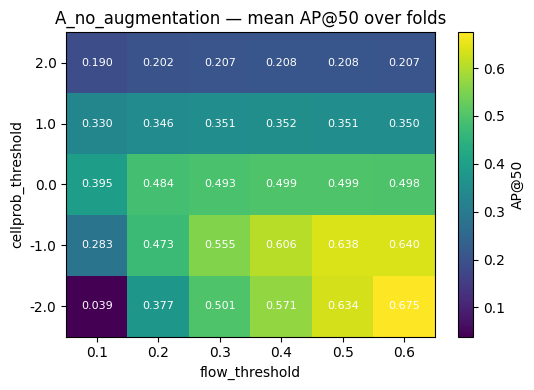

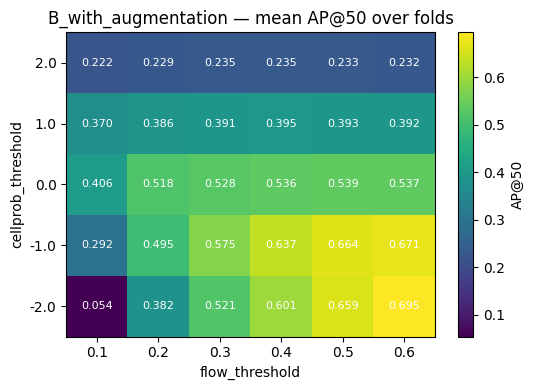

In [ ]:
# Optional: mean-over-folds AP@50 heatmap per condition (analogous to Fig. 3)
def plot_gridsearch_heatmap(condition):
    sub = grid_df[grid_df.condition == condition]
    piv = sub.pivot_table(index='cellprob', columns='flow', values='AP50', aggfunc='mean')
    fig, ax = plt.subplots(figsize=(5.5, 4))
    im = ax.imshow(piv.values, origin='lower', aspect='auto', cmap='viridis')
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
    ax.set_xlabel('flow_threshold'); ax.set_ylabel('cellprob_threshold')
    ax.set_title(f'{condition} — mean AP@50 over folds')
    for yi in range(piv.shape[0]):
        for xi in range(piv.shape[1]):
            ax.text(xi, yi, f'{piv.values[yi, xi]:.3f}', ha='center', va='center',
                    color='w', fontsize=8)
    fig.colorbar(im, ax=ax, label='AP@50')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'phase3_gridsearch_heatmap_{condition}.png', dpi=150,
                bbox_inches='tight')
    plt.show()

for cond in ['A_no_augmentation', 'B_with_augmentation']:
    plot_gridsearch_heatmap(cond)


## 7 · Test-fold re-evaluation (generalization)

Each model is now evaluated on **its own** cross-validation test fold with the parameters fixed:
morphology `diameter` + `min_size` and the per-model best `flow_threshold` / `cellprob_threshold`.
The output JSON mirrors your phase-2 files (adds an `inference_parameters` block).

In [ ]:
best_params = {(e['condition'], e['fold']): (e['best_flow_threshold'], e['best_cellprob_threshold'])
               for e in validation_report}
val_ap50 = {(e['condition'], e['fold']): e['best_validation_metrics']['AP@0.5']['AP']
            for e in validation_report}

test_report = []
for r in tqdm(registry, desc='models'):
    ft, cpt = best_params[(r['_condition'], r['fold'])]
    names = [str(n) for n in r['test_image_names']]

    imgs, gts, used = [], [], []
    for n in names:
        ip, gp = resolve_cv_pair(n, CV_IMAGES_DIR, CV_GT_DIR)
        if ip is None or gp is None:
            print(f'  !! missing CV files for id {n}  (img={ip}, gt={gp})')
            continue
        imgs.append(load_image_rgb(ip)); gts.append(load_masks(gp)); used.append(n)
    if not imgs:
        print(f'  !! no test images resolved for {r["_condition"]} fold {r["fold"]} — skipped')
        continue

    t0 = time.time(); model = load_model(r['model_path']); t_load = time.time() - t0
    t0 = time.time(); preds = eval_model(model, imgs, ft, cpt);    t_eval = time.time() - t0
    agg, per = compute_metrics(gts, preds)

    test_report.append(dict(
        fold=r['fold'], experiment=r['experiment'], condition=r['_condition'],
        model_name=r['model_name'], model_path=r['model_path'],
        use_augmentation=r['use_augmentation'],
        hyperparameters=dict(**TRAIN_HP,
                             augmentation_multiplier=r['hyperparameters'].get('augmentation_multiplier', 0)),
        inference_parameters=dict(diameter=DIAMETER, min_size=MIN_SIZE,
                                  flow_threshold=ft, cellprob_threshold=cpt,
                                  channel_axis=CHANNEL_AXIS),
        selected_on_validation=dict(flow_threshold=ft, cellprob_threshold=cpt,
                                    validation_AP50=val_ap50[(r['_condition'], r['fold'])]),
        n_train=r['n_train'], n_test=len(used), test_image_names=used,
        model_load_time_seconds=t_load, evaluation_time_seconds=t_eval,
        aggregate_metrics=agg, per_image_metrics=per))
    print(f"  {r['_condition']} fold {r['fold']}: flow={ft} cellprob={cpt}  "
          f"test AP@50={agg['AP@0.5']['AP']:.3f}  F1={agg['AP@0.5']['F1']:.3f}")
    del model; free_gpu()

save_json(test_report, OUTPUT_DIR / 'phase3_test_evaluation.json')


models:   0%|          | 0/10 [00:00<?, ?it/s]

  A_no_augmentation fold 1: flow=0.6 cellprob=-2.0  test AP@50=0.715  F1=0.822
  A_no_augmentation fold 2: flow=0.6 cellprob=-2.0  test AP@50=0.734  F1=0.840
  A_no_augmentation fold 3: flow=0.6 cellprob=-2.0  test AP@50=0.791  F1=0.880
  A_no_augmentation fold 4: flow=0.6 cellprob=-2.0  test AP@50=0.740  F1=0.844
  A_no_augmentation fold 5: flow=0.6 cellprob=-2.0  test AP@50=0.668  F1=0.804
  B_with_augmentation fold 1: flow=0.6 cellprob=-2.0  test AP@50=0.720  F1=0.825
  B_with_augmentation fold 2: flow=0.6 cellprob=-2.0  test AP@50=0.752  F1=0.846
  B_with_augmentation fold 3: flow=0.6 cellprob=-2.0  test AP@50=0.788  F1=0.876
  B_with_augmentation fold 4: flow=0.6 cellprob=-2.0  test AP@50=0.757  F1=0.864
  B_with_augmentation fold 5: flow=0.6 cellprob=-2.0  test AP@50=0.717  F1=0.837
saved -> /content/drive/MyDrive/Facul/ml_research/Refactor_IA_histology/modelos_finetunados/phase3_inference_optimization/phase3_test_evaluation.json


## 8 · Augmentation comparison (after inference optimization)

Aggregate the optimized **test-fold** results per condition (mean ± SD across folds) and apply the
same **one-standard-error rule** used elsewhere in the paper — with the parsimony tie-break favouring
the simpler pipeline (no augmentation) when the two are statistically indistinguishable.

In [ ]:
def collect(cond):
    return [e for e in test_report if e['condition'] == cond]

def fold_values(entries, thr='AP@0.5', field='AP'):
    return np.array([e['aggregate_metrics'][thr][field] for e in entries])

summary_rows = []
for cond in ['A_no_augmentation', 'B_with_augmentation']:
    ents = collect(cond)
    for thr in ['AP@0.5', 'AP@0.75', 'AP@0.9']:
        for field in ['AP', 'Precision', 'Recall', 'F1']:
            v = fold_values(ents, thr, field)
            summary_rows.append(dict(condition=cond, metric=thr, field=field,
                                     mean=v.mean(), std=v.std(ddof=1),
                                     se=v.std(ddof=1) / np.sqrt(len(v)), n_folds=len(v)))
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_DIR / 'phase3_augmentation_summary.csv', index=False)
print(summary_df[summary_df.field == 'AP'].to_string(index=False))


          condition  metric field     mean      std       se  n_folds
  A_no_augmentation  AP@0.5    AP 0.729744 0.044490 0.019896        5
  A_no_augmentation AP@0.75    AP 0.537409 0.056667 0.025342        5
  A_no_augmentation  AP@0.9    AP 0.035385 0.014177 0.006340        5
B_with_augmentation  AP@0.5    AP 0.746654 0.029461 0.013175        5
B_with_augmentation AP@0.75    AP 0.527258 0.042094 0.018825        5
B_with_augmentation  AP@0.9    AP 0.030394 0.011791 0.005273        5


In [ ]:
# one-standard-error rule on AP@50
a = fold_values(collect('A_no_augmentation'),  'AP@0.5', 'AP')
b = fold_values(collect('B_with_augmentation'), 'AP@0.5', 'AP')
better = a if a.mean() >= b.mean() else b
se_best = better.std(ddof=1) / np.sqrt(len(better))
threshold = better.mean() - se_best

print(f'AP@50  no-aug = {a.mean():.3f} ± {a.std(ddof=1):.3f}   '
      f'aug = {b.mean():.3f} ± {b.std(ddof=1):.3f}')
print(f'1-SE threshold (from better config) = {threshold:.3f}')
if abs(a.mean() - b.mean()) <= se_best:
    print('=> within 1 SE: statistically equivalent -> prefer the SIMPLER pipeline (NO augmentation).')
else:
    print(f'=> difference exceeds 1 SE -> prefer '
          f'{"augmentation" if b.mean() > a.mean() else "no augmentation"}.')


AP@50  no-aug = 0.730 ± 0.044   aug = 0.747 ± 0.029
1-SE threshold (from better config) = 0.733
=> difference exceeds 1 SE -> prefer augmentation.


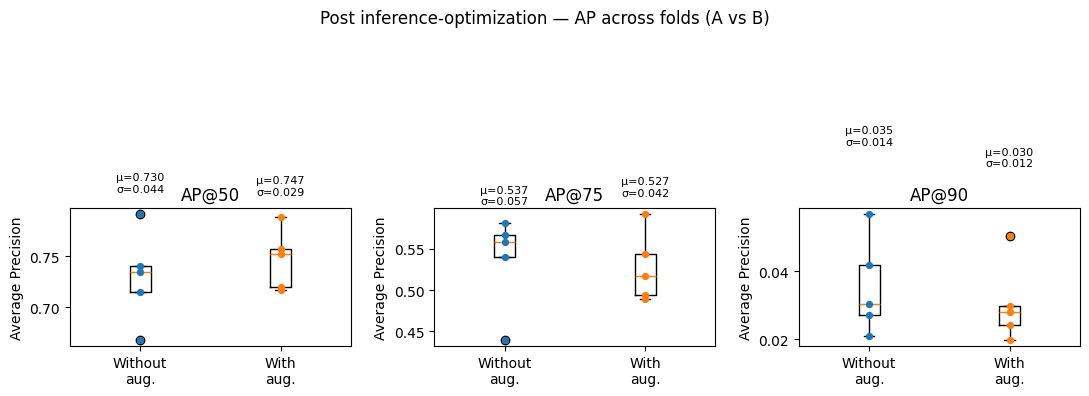

In [ ]:
# Figure-5-style box plot for the optimized results
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
titles = {'AP@0.5': 'AP@50', 'AP@0.75': 'AP@75', 'AP@0.9': 'AP@90'}
for ax, thr in zip(axes, ['AP@0.5', 'AP@0.75', 'AP@0.9']):
    va = fold_values(collect('A_no_augmentation'),  thr, 'AP')
    vb = fold_values(collect('B_with_augmentation'), thr, 'AP')
    ax.boxplot([va, vb])
    ax.set_xticks([1, 2]); ax.set_xticklabels(['Without\naug.', 'With\naug.'])
    ax.set_title(titles[thr]); ax.set_ylabel('Average Precision')
    for i, v in enumerate([va, vb], start=1):
        ax.scatter(np.full_like(v, i), v, zorder=3, s=18)
        ax.text(i, v.max() + 0.02, f'μ={v.mean():.3f}\nσ={v.std(ddof=1):.3f}',
                ha='center', va='bottom', fontsize=8)
fig.suptitle('Post inference-optimization — AP across folds (A vs B)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase3_augmentation_boxplot.png', dpi=200, bbox_inches='tight')
plt.show()


## 9 · Change vs phase-2 (default thresholds)

Per-fold delta between the phase-2 test metrics (default inference: `diameter=None`, default
`min_size`, `flow=0.4`, `cellprob=0.0`) and the phase-3 optimized test metrics on the same folds.
Positive = improvement. This isolates the combined effect of the inference-parameter refinement.

In [ ]:
delta_rows = []
for e in test_report:
    ph2 = next(r for r in registry
               if r['_condition'] == e['condition'] and r['fold'] == e['fold'])
    for thr in ['AP@0.5', 'AP@0.75', 'AP@0.9']:
        before = ph2['aggregate_metrics'][thr]['AP']
        after  = e['aggregate_metrics'][thr]['AP']
        delta_rows.append(dict(condition=e['condition'], fold=e['fold'], metric=thr,
                               phase2_default=before, phase3_optimized=after,
                               delta=after - before))
delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(OUTPUT_DIR / 'phase3_vs_phase2_delta.csv', index=False)
print(delta_df.pivot_table(index=['condition', 'fold'], columns='metric',
                           values='delta').round(3).to_string())
print('\nMean delta by condition:')
print(delta_df.groupby(['condition', 'metric'])['delta'].mean().round(3).to_string())


metric                    AP@0.5  AP@0.75  AP@0.9
condition           fold                         
A_no_augmentation   1     -0.013   -0.092  -0.108
                    2     -0.032   -0.085  -0.033
                    3      0.033   -0.104  -0.102
                    4     -0.009   -0.050  -0.051
                    5     -0.033   -0.187  -0.109
B_with_augmentation 1     -0.026   -0.120  -0.129
                    2     -0.003   -0.127  -0.069
                    3      0.023   -0.174  -0.140
                    4      0.005   -0.075  -0.085
                    5      0.003   -0.138  -0.104

Mean delta by condition:
condition            metric 
A_no_augmentation    AP@0.5    -0.011
                     AP@0.75   -0.104
                     AP@0.9    -0.080
B_with_augmentation  AP@0.5     0.000
                     AP@0.75   -0.127
                     AP@0.9    -0.105


In [ ]:
# tabela dos 10, do melhor pro pior
best_df.sort_values('val_AP50', ascending=False)

# o melhor modelo/fold isolado
best_df.sort_values('val_AP50', ascending=False).iloc[0]

,7
condition,B_with_augmentation
fold,3
flow,0.6
cellprob,-2.0
val_AP50,0.754001
